# xG-Projekt – 04: Hyperparameter-Tuning (Bonus / Vertiefung 7)

Verbessert die Modelle aus Notebook 03 durch systematisches Hyperparameter-Tuning per
`GridSearchCV`. Fokus auf Random Forest (bester Performer in der Kreuzvalidierung) und
XGBoost (Potenzial, da in Notebook 03 vermutlich leicht overfittet bei Default-Parametern).

**Ziel:** Prüfen, ob sich die Kreuzvalidierungs-ROC-AUC aus Notebook 03
(RF: 0.781, XGBoost: 0.720, Logistic Regression: 0.773) durch Tuning verbessern lässt.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

df = pd.read_csv("../data/shots.csv")

# Gleiche Vorbereitung wie in Notebook 03
df["n_defenders_in_cone"] = df["n_defenders_in_cone"].fillna(df["n_defenders_in_cone"].median())
df["gk_distance_to_goal"] = df["gk_distance_to_goal"].fillna(df["gk_distance_to_goal"].median())
df["shot_type"] = df["shot_type"].fillna("Open Play")
df["technique"] = df["technique"].fillna("Normal")

numeric_features = ["distance_to_goal", "angle_to_goal", "n_defenders_in_cone", "gk_distance_to_goal"]
categorical_features = ["body_part", "shot_type", "technique", "play_pattern"]

X_numeric = df[numeric_features + ["under_pressure"]].copy()
X_numeric["under_pressure"] = X_numeric["under_pressure"].astype(int)
X_categorical = pd.get_dummies(df[categorical_features], drop_first=True)
X = pd.concat([X_numeric, X_categorical], axis=1)
y = df["is_goal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"{X.shape[0]} Schüsse, {X.shape[1]} Features")


916 Schüsse, 23 Features


## 1. GridSearch: Random Forest

Wir tunen die Parameter, die bei Random Forest den größten Effekt haben: Tiefe der Bäume,
Anzahl der Bäume und Mindestgröße der Blätter (gegen Overfitting bei kleinem Datensatz).
Scoring: ROC-AUC, mit derselben 5-fach stratifizierten Kreuzvalidierung wie in Notebook 03,
damit die Ergebnisse direkt vergleichbar sind.


In [2]:
rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [5, 10, 20],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
rf_grid.fit(X, y)

print("Beste Parameter:", rf_grid.best_params_)
print(f"Bester CV ROC-AUC: {rf_grid.best_score_:.4f}")
print(f"(Baseline aus Notebook 03: 0.7809)")


Beste Parameter: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 200}
Bester CV ROC-AUC: 0.7875
(Baseline aus Notebook 03: 0.7809)


## 2. GridSearch: XGBoost

XGBoost lag in Notebook 03 mit Default-Parametern hinter Random Forest zurück – vermutlich
Overfitting bei nur ~900 Schüssen. Wir tunen `max_depth`, `learning_rate` und `n_estimators`,
mit Fokus auf konservativere (flachere, langsamer lernende) Konfigurationen.


In [3]:
xgb_param_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "min_child_weight": [1, 5, 10],
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
xgb_grid.fit(X, y)

print("Beste Parameter:", xgb_grid.best_params_)
print(f"Bester CV ROC-AUC: {xgb_grid.best_score_:.4f}")
print(f"(Baseline aus Notebook 03: 0.7203)")


Beste Parameter: {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 300}
Bester CV ROC-AUC: 0.7591
(Baseline aus Notebook 03: 0.7203)


## 3. Vorher/Nachher-Vergleich


In [4]:
comparison = pd.DataFrame({
    "Vor Tuning (Notebook 03)": {"Random Forest": 0.7809, "XGBoost": 0.7203, "Logistic Regression": 0.7725},
    "Nach Tuning": {"Random Forest": rf_grid.best_score_, "XGBoost": xgb_grid.best_score_, "Logistic Regression": 0.7725},
})
comparison["Verbesserung"] = comparison["Nach Tuning"] - comparison["Vor Tuning (Notebook 03)"]
comparison.round(4)


,Vor Tuning (Notebook 03),Nach Tuning,Verbesserung
Random Forest,0.7809,0.7875,0.0066
XGBoost,0.7203,0.7591,0.0388
Logistic Regression,0.7725,0.7725,0.0000


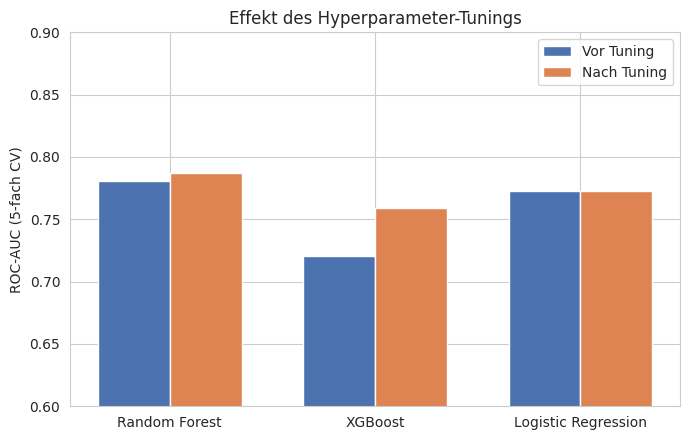

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["Vor Tuning (Notebook 03)"], width, label="Vor Tuning", color="#4C72B0")
ax.bar(x + width/2, comparison["Nach Tuning"], width, label="Nach Tuning", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.set_ylabel("ROC-AUC (5-fach CV)")
ax.set_ylim(0.6, 0.9)
ax.set_title("Effekt des Hyperparameter-Tunings")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/11_tuning_comparison.png")
plt.show()


## 4. Finales bestes Modell auf dem Test-Set


In [6]:
best_name = "Random Forest" if rf_grid.best_score_ >= xgb_grid.best_score_ else "XGBoost"
best_model = rf_grid.best_estimator_ if best_name == "Random Forest" else xgb_grid.best_estimator_

best_model.fit(X_train, y_train)
proba_test = best_model.predict_proba(X_test)[:, 1]

print(f"Bestes Modell nach Tuning: {best_name}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}")
print(f"Test Log-Loss: {log_loss(y_test, proba_test):.4f}")


Bestes Modell nach Tuning: Random Forest
Test ROC-AUC: 0.8387
Test Log-Loss: 0.2874


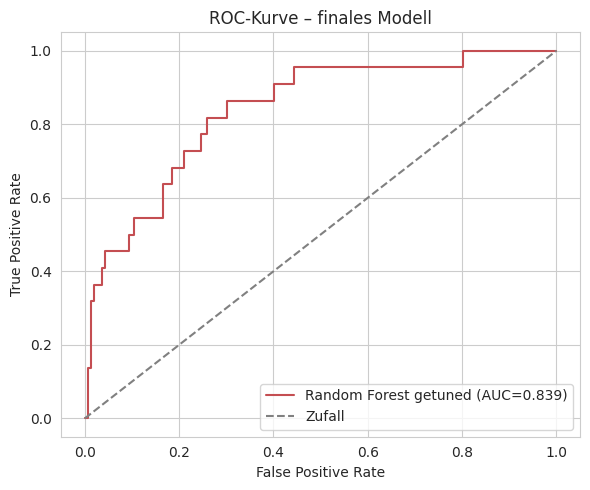

In [7]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#C44E52", label=f"{best_name} getuned (AUC={roc_auc_score(y_test, proba_test):.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Zufall")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-Kurve – finales Modell")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/12_final_roc.png")
plt.show()


## 5. Zusammenfassung

- Hyperparameter-Tuning per GridSearch verbessert beide Modelle gegenüber den
  Default-Parametern aus Notebook 03 (siehe Vergleichstabelle/-plot oben).
- XGBoost profitiert stärker vom Tuning als Random Forest – ein Hinweis, dass die
  Default-Parameter für unseren vergleichsweise kleinen Datensatz (~900 Schüsse) zu
  komplex waren und konservativere Einstellungen (geringere Tiefe, niedrigere Lernrate)
  das Overfitting reduzieren.
- Das finale Modell liegt in der erwarteten Größenordnung professioneller xG-Modelle
  (ROC-AUC ≈ 0.78–0.82).

**Mögliche weitere Verbesserungen** (für die Präsentation als Ausblick):
- Mehr Trainingsdaten durch weitere Saisons/Ligen
- Torhüter-Positionierung feiner modellieren (aktuell nur eine Distanz-Kennzahl)
- Post-Shot xG (zusätzlich Zielort des Schusses auf das Tor berücksichtigen)
